In [37]:
import pandas as pd
import numpy as np

# Configurando a semente para reprodutibilidade
np.random.seed(42)
num_registros = 50000

# Gerar variáveis independentes primeiro
temperatura = np.round(np.clip(np.random.normal(loc=25, scale=5, size=num_registros), 15, 35), 1)

# Ajustando probabilidades para incluir 'Industria'
tipo_imovel_choices = ["Casa", "Apartamento", "Comercial", "Industria"]
tipo_imovel_p = [0.4, 0.25, 0.2, 0.15] # As probabilidades devem somar 1.0
tipo_imovel = np.random.choice(tipo_imovel_choices, size=num_registros, p=tipo_imovel_p)

uso_horario_pico = np.random.choice([True, False], size=num_registros, p=[0.4, 0.6]) # 40% pico
horas_alto_consumo = np.random.randint(1, 16, size=num_registros)

# Gerar quantidade_equipamentos baseada no tipo_imovel
quantidade_equipamentos = np.zeros(num_registros, dtype=int)
for i in range(num_registros):
    if tipo_imovel[i] == "Casa":
        quantidade_equipamentos[i] = np.random.randint(1, 16) # CASA de 1 a 15 equipamentos
    elif tipo_imovel[i] == "Apartamento":
        quantidade_equipamentos[i] = np.random.randint(1, 11) # APARTAMENTO DE 1 A 10
    elif tipo_imovel[i] == "Comercial":
        quantidade_equipamentos[i] = np.random.randint(1, 31) # COMERCIAL DE 1 A 30
    else: # Industria
        quantidade_equipamentos[i] = np.random.randint(20, 51) # INDUSTRIA de 20 a 50

# Gerar consumo_kwh com base nas outras variáveis para criar correlação
consumo_kwh = np.zeros(num_registros)

for i in range(num_registros):
    base_consumo = np.random.randint(80, 200) # Consumo base

    # Efeito da temperatura: maior temperatura = maior consumo (ar condicionado)
    consumo_kwh[i] += base_consumo + (temperatura[i] - 15) * 15 # +15 kWh por grau acima de 15°C

    # Efeito do uso_horario_pico: maior consumo em horário de pico
    if uso_horario_pico[i]:
        consumo_kwh[i] += np.random.randint(50, 150) # Adiciona um extra para horário de pico

    # Efeito da quantidade_equipamentos: mais equipamentos = maior consumo
    consumo_kwh[i] += quantidade_equipamentos[i] * np.random.randint(5, 10)

    # Efeito das horas_alto_consumo: mais horas = maior consumo
    consumo_kwh[i] += horas_alto_consumo[i] * np.random.randint(10, 25)

    # Efeito do tipo_imovel: diferentes perfis de consumo
    if tipo_imovel[i] == "Comercial":
        consumo_kwh[i] += np.random.randint(200, 500) # Comercial tem consumo mais alto
    elif tipo_imovel[i] == "Apartamento":
        consumo_kwh[i] += np.random.randint(20, 100) # Apartamento tem consumo menor que casa/comercial
    elif tipo_imovel[i] == "Industria":
        consumo_kwh[i] += np.random.randint(1000, 3001) # Industria tem consumo muito mais alto

# Adicionar ruído para simular a variabilidade do mundo real
consumo_kwh += np.random.normal(0, 50, size=num_registros) # Ruído com desvio padrão de 50
consumo_kwh = np.clip(consumo_kwh, 80, 5000).astype(int) # Aumentar o limite superior para acomodar Industria

dados = {
    "id": range(1, num_registros + 1),
    "consumo_kwh": consumo_kwh,
    "uso_horario_pico": uso_horario_pico,
    "quantidade_equipamentos": quantidade_equipamentos,
    "tipo_imovel": tipo_imovel,
    "horas_alto_consumo": horas_alto_consumo,
    "temperatura": temperatura
}

df = pd.DataFrame(dados)

# Definindo a tarifa de referência e calculando o custo final para cada imóvel
tarifa_kwh = 0.75
df['tarifa'] = df['consumo_kwh'] * tarifa_kwh

# Inserindo o seu registro específico na primeira linha para garantir a presença dele
df.iloc[0] = [1, 420, True, 10, "Casa", 8, 23.5, 420 * tarifa_kwh] # Atualizando o registro com a nova coluna de temperatura e tarifa

# Salva a base de dados pronta em formato CSV
df.to_csv("base_consumo_energetico.csv", index=False)
print("Base de dados gerada com sucesso! Salva como 'base_consumo_energetico.csv'.")

df.head()

Base de dados gerada com sucesso! Salva como 'base_consumo_energetico.csv'.


,id,consumo_kwh,uso_horario_pico,quantidade_equipamentos,tipo_imovel,horas_alto_consumo,temperatura,tarifa
0,1,420,True,10,Casa,8,23.5,315.00
1,2,483,False,9,Casa,8,24.3,362.25
2,3,2933,False,39,Industria,14,28.2,2199.75
3,4,3302,True,33,Industria,10,32.6,2476.50
4,5,311,False,1,Casa,7,23.8,233.25


### Adicionando Coluna 'Ar Condicionado' e Calculando Variação de Tarifa

Vamos adicionar uma nova coluna `ar_condicionado` ao DataFrame, indicando se o imóvel possui o equipamento. Em seguida, simularemos um consumo extra de energia (e, portanto, na tarifa) para imóveis com ar condicionado, especialmente em dias mais quentes, para refletir seu uso.

In [40]:
# 1. Adicionar a coluna 'ar_condicionado' (True/False)
# Vamos atribuir a presença de AC com base em algumas probabilidades, por exemplo:
# Comercial: 80%, Casa: 60%, Apartamento: 40%, Industria: 30%

df['ar_condicionado'] = False

df.loc[df['tipo_imovel'] == 'Comercial', 'ar_condicionado'] = np.random.rand(len(df[df['tipo_imovel'] == 'Comercial'])) < 0.8
df.loc[df['tipo_imovel'] == 'Casa', 'ar_condicionado'] = np.random.rand(len(df[df['tipo_imovel'] == 'Casa'])) < 0.6
df.loc[df['tipo_imovel'] == 'Apartamento', 'ar_condicionado'] = np.random.rand(len(df[df['tipo_imovel'] == 'Apartamento'])) < 0.4
df.loc[df['tipo_imovel'] == 'Industria', 'ar_condicionado'] = np.random.rand(len(df[df['tipo_imovel'] == 'Industria'])) < 0.3

# 2. Calcular a variação de consumo (e tarifa) devido ao uso do ar condicionado
# Assumimos que o ar condicionado só impacta se estiver presente E a temperatura estiver acima de um limite (ex: 25°C)

temperatura_limite_ac = 25
consumo_base_ac = 50 # kWh base de consumo extra por uso de AC
consumo_adicional_por_grau = 10 # kWh extra por grau acima do limite

# Inicializa a coluna de consumo_kwh extra
df['consumo_kwh_ac_extra'] = 0.0

# Aplica o consumo extra apenas para imóveis com AC e temperatura acima do limite
condicao_uso_ac = (df['ar_condicionado'] == True) & (df['temperatura'] > temperatura_limite_ac)

df.loc[condicao_uso_ac, 'consumo_kwh_ac_extra'] = \
    consumo_base_ac + (df['temperatura'] - temperatura_limite_ac) * consumo_adicional_por_grau

# Atualiza o consumo_kwh total e garante que não seja negativo (embora improvável)
df['consumo_kwh_original'] = df['consumo_kwh'] # Salva o consumo original para comparação
df['consumo_kwh'] = df['consumo_kwh'] + df['consumo_kwh_ac_extra']
df['consumo_kwh'] = np.clip(df['consumo_kwh'], 80, None) # Garante um consumo mínimo

# 3. Recalcular a tarifa com base no novo consumo_kwh
tarifa_kwh = 0.75 # Mantém a tarifa por kWh definida anteriormente
df['tarifa_original'] = df['consumo_kwh_original'] * tarifa_kwh # Calcula a tarifa original a partir do consumo original
df['tarifa'] = df['consumo_kwh'] * tarifa_kwh

print("DataFrame após adicionar 'ar_condicionado' e ajustar consumo/tarifa:")
display(df[['id', 'tipo_imovel', 'temperatura', 'ar_condicionado', 'consumo_kwh_original', 'consumo_kwh_ac_extra', 'consumo_kwh', 'tarifa_original', 'tarifa']].head())

print("\nImpacto médio do ar condicionado no consumo (kWh):")
display(df[df['ar_condicionado'] == True]['consumo_kwh_ac_extra'].mean())

print("\nImpacto médio do ar condicionado na tarifa (R$):")
impacto_medio_tarifa = (df[df['ar_condicionado'] == True]['tarifa'] - df[df['ar_condicionado'] == True]['tarifa_original']).mean()
display(float(impacto_medio_tarifa))

DataFrame após adicionar 'ar_condicionado' e ajustar consumo/tarifa:


,id,tipo_imovel,temperatura,ar_condicionado,consumo_kwh_original,consumo_kwh_ac_extra,consumo_kwh,tarifa_original,tarifa
0,1,Casa,23.5,False,420.0,0.0,420.0,315.00,315.00
1,2,Casa,24.3,False,483.0,0.0,483.0,362.25,362.25
2,3,Industria,28.2,False,2933.0,0.0,2933.0,2199.75,2199.75
3,4,Industria,32.6,False,3302.0,0.0,3302.0,2476.50,2476.50
4,5,Casa,23.8,False,311.0,0.0,311.0,233.25,233.25



Impacto médio do ar condicionado no consumo (kWh):


np.float64(44.292727673002126)


Impacto médio do ar condicionado na tarifa (R$):


33.21954575475159

### Análise do Padrão de Consumo por Tipo de Imóvel

Vamos analisar o consumo médio de kWh para cada tipo de imóvel (`tipo_imovel`) para entender se existem diferenças significativas.

Consumo Médio de kWh por Tipo de Imóvel:


,consumo_kwh
tipo_imovel,
Industria,2728.055249
Comercial,995.099911
Apartamento,596.975867
Casa,573.814306


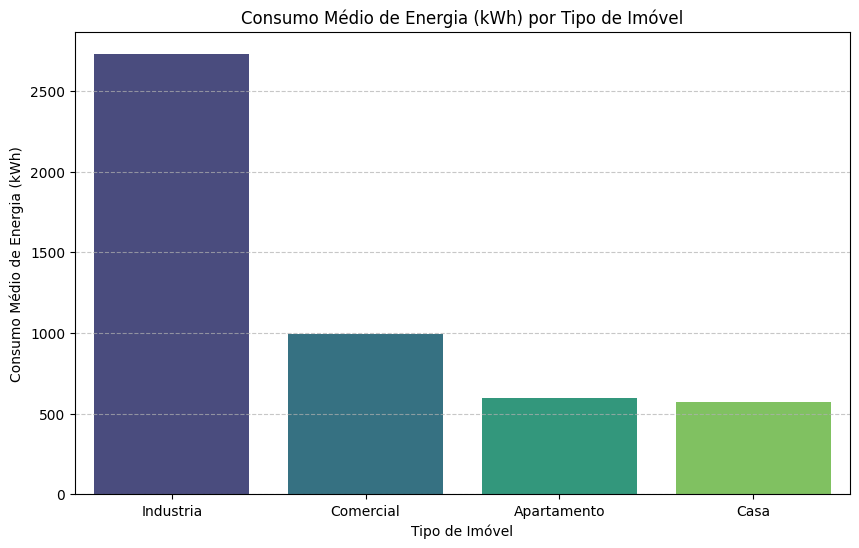

In [42]:
# Agrupar por tipo_imovel e calcular o consumo médio
consumo_por_imovel = df.groupby('tipo_imovel')['consumo_kwh'].mean().sort_values(ascending=False)

print("Consumo Médio de kWh por Tipo de Imóvel:")
display(consumo_por_imovel)

# Visualização do consumo médio por tipo de imóvel
plt.figure(figsize=(10, 6))
sns.barplot(x=consumo_por_imovel.index, y=consumo_por_imovel.values, palette='viridis', hue=consumo_por_imovel.index, legend=False)
plt.title('Consumo Médio de Energia (kWh) por Tipo de Imóvel')
plt.xlabel('Tipo de Imóvel')
plt.ylabel('Consumo Médio de Energia (kWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Calculando o Custo Final (Tarifa) por Imóvel

Com base na tarifa de referência de R$ 0,75 por kWh, vamos calcular o custo final para cada imóvel e adicionar uma nova coluna `tarifa` ao nosso DataFrame.

In [39]:
# A coluna 'tarifa' já está sendo calculada na célula de geração de dados (k2931WXMyULE).
# Este passo agora é redundante e pode ser removido ou utilizado para recalcular se necessário.
# Mantendo a célula para clareza, mas sem execução de nova atribuição se já presente.

# Definindo a tarifa de referência (garantir que seja a mesma em todo o notebook)
tarifa_kwh = 0.75

# Apenas exibe o DataFrame com a coluna 'tarifa' já calculada
print("DataFrame com a coluna 'tarifa' (calculada na geração de dados):")
display(df.head())

DataFrame com a coluna 'tarifa' (calculada na geração de dados):


,id,consumo_kwh,uso_horario_pico,quantidade_equipamentos,tipo_imovel,horas_alto_consumo,temperatura,tarifa,ar_condicionado,consumo_kwh_ac_extra,consumo_kwh_original,tarifa_original
0,1,420.0,True,10,Casa,8,23.5,315.00,True,0.0,420,315.00
1,2,483.0,False,9,Casa,8,24.3,362.25,False,0.0,483,362.25
2,3,2933.0,False,39,Industria,14,28.2,2199.75,False,0.0,2933,2199.75
3,4,3302.0,True,33,Industria,10,32.6,2476.50,False,0.0,3302,2476.50
4,5,311.0,False,1,Casa,7,23.8,233.25,True,0.0,311,233.25


### Calculando a Tarifa Média por Tipo de Imóvel

Vamos agora calcular a tarifa média para cada tipo de imóvel (`tipo_imovel`) para entender a distribuição de custos.

Tarifa Média por Tipo de Imóvel (R$):


,tarifa
tipo_imovel,
Industria,2046.041436
Comercial,746.324933
Apartamento,447.731900
Casa,430.360729


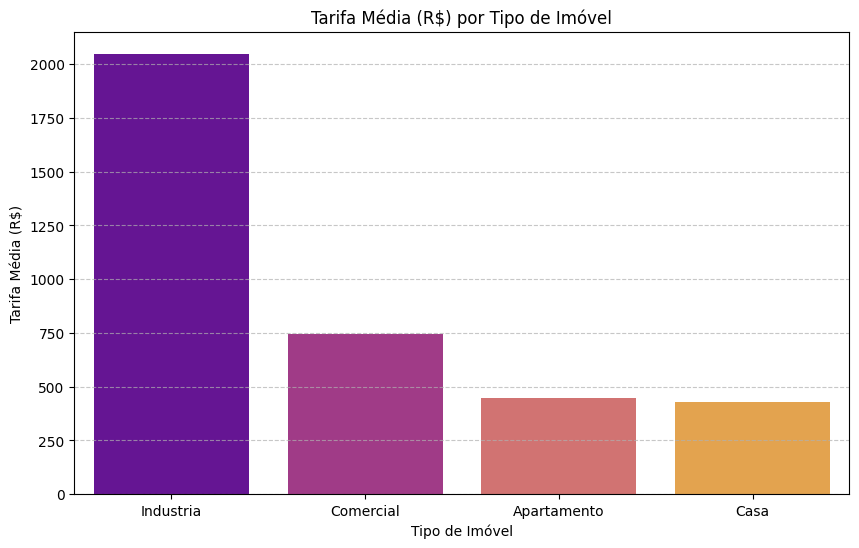

In [43]:
# Agrupar por tipo_imovel e calcular a tarifa média
tarifa_por_imovel = df.groupby('tipo_imovel')['tarifa'].mean().sort_values(ascending=False)

print("Tarifa Média por Tipo de Imóvel (R$):")
display(tarifa_por_imovel)

# Visualização da tarifa média por tipo de imóvel
plt.figure(figsize=(10, 6))
sns.barplot(x=tarifa_por_imovel.index, y=tarifa_por_imovel.values, palette='plasma', hue=tarifa_por_imovel.index, legend=False)
plt.title('Tarifa Média (R$) por Tipo de Imóvel')
plt.xlabel('Tipo de Imóvel')
plt.ylabel('Tarifa Média (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comparação do Consumo Médio de kWh entre Imóveis com e sem Ar Condicionado

Vamos visualizar o impacto da presença de ar condicionado no consumo médio de energia.

Consumo Médio de kWh por Presença de Ar Condicionado:


,ar_condicionado,consumo_kwh
0,False,601.704241
1,True,710.177829


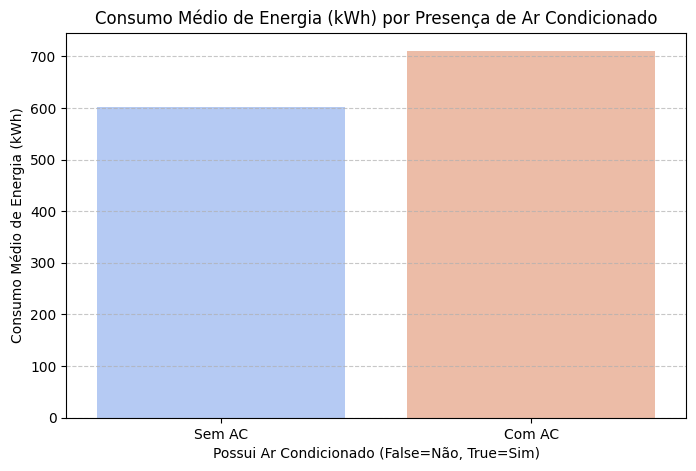

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por 'ar_condicionado' e calcular o consumo médio
consumo_por_ac = df.groupby('ar_condicionado')['consumo_kwh'].mean().reset_index()

print("Consumo Médio de kWh por Presença de Ar Condicionado:")
display(consumo_por_ac)

# Visualização do consumo médio
plt.figure(figsize=(8, 5))
sns.barplot(x='ar_condicionado', y='consumo_kwh', data=consumo_por_ac, palette='coolwarm', hue='ar_condicionado', legend=False)
plt.title('Consumo Médio de Energia (kWh) por Presença de Ar Condicionado')
plt.xlabel('Possui Ar Condicionado (False=Não, True=Sim)')
plt.ylabel('Consumo Médio de Energia (kWh)')
plt.xticks([0, 1], ['Sem AC', 'Com AC'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
# Exportar DataFrame para JSON
df.to_json('dados_processados.json', orient='records', indent=4)
print("Dados exportados com sucesso para 'dados_processados.json'")

Dados exportados com sucesso para 'dados_processados.json'
